# 連合学習チュートリアル（第2回・垂直連合学習）　模範解答

第1回では **水平連合学習**（みんなが同じ種類のデータを別々に持っている場合）を学びました。
第2回のテーマは **垂直連合学習（Vertical Federated Learning, VFL）** です。

> **今日の物語**
> 同じ人たちについて、**バラバラの情報**を別々の組織が持っている。
> データそのものは渡さず、**中間の特徴と勾配だけ**をやり取りして、
> みんなで1つの賢いAIを作れるだろうか？

このノートブックは **模範解答** です。


## 0. はじめに：前回（水平連合学習）の復習

本題に入る前に、前回の内容をふりかえりましょう。

### 前回やったこと
前回は **水平連合学習（Horizontal Federated Learning）** を学びました。
たくさんの参加者が **同じ種類のデータを別々に** 持っている状況で、
**データそのものを共有せず**に、みんなで1つのAIを育てる方法です。

- 例：A病院とB病院が、それぞれ **別の患者の** 同じ検査データを持っている
- 各参加者が自分のデータでモデルを学習し、**モデルの重み（パラメータ）だけ**を持ち寄って合体させる（FedAvg）
- 前回は手書き画像データを使い、1台だけで学習・全部集めて学習・連合学習の3つを比較

### 今回やること
今回の **垂直連合学習（Vertical Federated Learning）** は、データの分け方が前回とまったく違います。
**同じ人たちについて、違う種類の情報（特徴）を別々の参加者が持っている**状況を扱います。

- 例：ある人について、**病院は検査値**を、**薬局は薬の購入履歴**を、**銀行は収入**を持っている
- 誰も全部の情報は持っていない。データを見せ合わずに協力できるか？

### 水平 と 垂直 のちがい（まとめ）

| 観点 | 水平FL（前回） | 垂直FL（今回） |
|---|---|---|
| データの分け方 | 同じ種類の情報を人ごとに分ける（行で分割） | 同じ人について違う情報で分ける（列で分割） |
| たとえ | A病院とB病院が、別々の患者の同じ検査値を持つ | 同じ患者の、検査値は病院・薬の履歴は薬局が持つ |
| やり取りするもの | モデルの重み（パラメータ） | 中間の特徴と勾配 |
| 共通する大事な点 | 生データそのものは外に出さない | 生データそのものは外に出さない |

分け方とやり取りするものが変わりますが、**生データを共有しないという連合学習の核心は同じ**です。

このあと **1章** で準備をしたら、まず **前回の水平FLを1回だけ実際に動かして** 思い出し、
そのあと今回の垂直FLに入ります。


## 1. 準備：必要なライブラリの読み込み

In [1]:
!pip install -q torch scikit-learn matplotlib pandas
# 前回の復習（水平FL）で使う画像データ取得用
!pip install -q "flwr-datasets[vision]>=0.5.0"
# 日本語グラフ用フォント（入らない環境ではフォールバックします）
!pip install -q japanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 48.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# 日本語フォントの読み込み（japanize-matplotlib が使えない場合はフォント名でフォールバック）
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib  # これだけで日本語が出るようになる
except Exception:
    import matplotlib
    for cand in ["IPAexGothic", "Noto Sans CJK JP", "TakaoPGothic", "MS Gothic"]:
        try:
            matplotlib.rcParams["font.family"] = cand
            break
        except Exception:
            continue
    matplotlib.rcParams["axes.unicode_minus"] = False
print("日本語フォント設定: 完了")

日本語フォント設定: 完了


In [3]:
# このチュートリアル全体で使うライブラリ
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
import os, urllib.request, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# このチュートリアルは CPU 固定（GPUは使いません）
def get_default_device():
    return torch.device("cpu")
DEVICE = get_default_device()

# 全体で使う設定
NUM_CLIENTS = 3   # 垂直FLの参加者数（特徴を3グループに分けます）
EMB_DIM = 4       # 各参加者が出す中間の特徴の次元
HIDDEN  = 32      # サーバーモデルの隠れ層のサイズ
print("準備完了。参加者は", NUM_CLIENTS, "人で進めます。")

準備完了。参加者は 3 人で進めます。


## 1-A. 復習デモ：前回の水平連合学習を1回だけ動かす

垂直FLに入る前に、**前回の水平連合学習を1回だけ実際に動かして**思い出しましょう。

- 題材：前回と同じ **Fashion-MNIST**（服の画像を10種類に分類）
- 設定：**5人**の参加者が、**1人2000枚ずつ**バラバラに画像を持っている（行で分割＝水平）
- 各参加者が自分の手元で学習し、**モデルの重みだけ**を持ち寄って平均する（FedAvg）
- データそのものは一度も共有しません

> 数十秒で終わります。精度が少しずつ上がっていく様子を観察してください。


In [4]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import IidPartitioner

# 前回と同じ Fashion-MNIST を、5人にバラバラ（IID）に配る
H_NUM_CLIENTS = 5      # 参加者の数
H_PER_CLIENT  = 2000   # 1人あたりの枚数
fds = FederatedDataset(
    dataset="zalando-datasets/fashion_mnist",
    partitioners={"train": IidPartitioner(num_partitions=H_NUM_CLIENTS)})

def _part_to_tensor(ds, n):
    ds = ds.select(range(min(n, len(ds))))
    X = np.stack([np.array(im, dtype=np.float32) / 255.0 for im in ds["image"]]).reshape(len(ds), -1)
    y = np.array(ds["label"])
    return torch.tensor(X), torch.tensor(y)

# 各参加者のデータ（1人2000枚）
h_clients = [_part_to_tensor(fds.load_partition(i), H_PER_CLIENT) for i in range(H_NUM_CLIENTS)]
# テスト用データ（精度を測る用）
h_test = fds.load_split("test").select(range(2000))
H_Xte = torch.tensor(np.stack([np.array(im, dtype=np.float32) / 255.0 for im in h_test["image"]]).reshape(2000, -1))
H_yte = torch.tensor(np.array(h_test["label"]))
print(f"準備完了：{H_NUM_CLIENTS}人 × {H_PER_CLIENT}枚")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

準備完了：5人 × 2000枚


In [5]:
# 画像を分類する小さなモデル
class ImageNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x):
        return self.net(x)

def h_evaluate(model):
    model.eval()
    with torch.no_grad():
        return (model(H_Xte).argmax(1) == H_yte).float().mean().item() * 100

In [6]:
%%time
# 水平連合学習（FedAvg）を1回だけ動かす
H_ROUNDS = 20       # 持ち寄って合体する回数
H_LOCAL_EPOCHS = 5  # 各参加者が自分の手元で学習する回数
H_LR = 0.1

global_model = ImageNet()
h_history = []
for r in range(H_ROUNDS):
    local_states = []
    for Xc, yc in h_clients:
        # 各参加者：いまの共通モデルを受け取り、自分のデータで学習する
        m = ImageNet(); m.load_state_dict(global_model.state_dict())
        opt = torch.optim.SGD(m.parameters(), lr=H_LR); crit = nn.CrossEntropyLoss()
        for _ in range(H_LOCAL_EPOCHS):
            opt.zero_grad(); crit(m(Xc), yc).backward(); opt.step()
        local_states.append(m.state_dict())   # 重みだけを持ち寄る（データは渡さない）
    # サーバー：みんなの重みを平均して新しい共通モデルにする（これがFedAvg）
    new_state = {k: sum(s[k] for s in local_states) / len(local_states)
                 for k in global_model.state_dict()}
    global_model.load_state_dict(new_state)
    h_history.append(h_evaluate(global_model))

print(f"水平FLの最終精度: {h_history[-1]:.1f}%")

水平FLの最終精度: 71.0%
CPU times: user 17 s, sys: 473 ms, total: 17.5 s
Wall time: 18.4 s


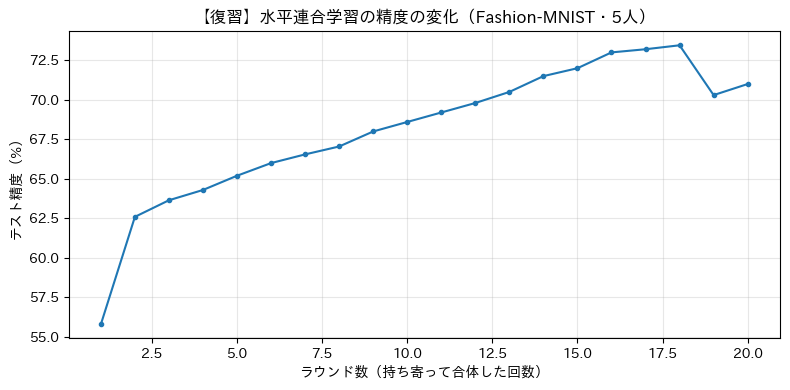

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(h_history)+1), h_history, marker="o", markersize=3)
plt.xlabel("ラウンド数（持ち寄って合体した回数）"); plt.ylabel("テスト精度（%）")
plt.title("【復習】水平連合学習の精度の変化（Fashion-MNIST・5人）")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

データを共有せず、重みを持ち寄るだけで精度が上がっていきます。これが水平連合学習でした。

では本題の **垂直連合学習** に入りましょう。


## 2. 例題：ワインの種類を当てる垂直連合学習

まずは、これから作る垂直連合学習の**完成形**を、ワインのデータで一度見てみましょう。
この例題で全体の流れをつかんでから、次の章で自分の手で組み立てます（演習）。

**お題：ワインの化学成分から品種を当てる**

ワインの化学成分（アルコール度数・色の濃さなど）を手がかりに、ある品種かどうかを当てます。
今回は、これらの成分を **3つのグループ** に分け、別々のグループが持っているとします。
グループどうしでデータを見せ合わずに、力を合わせて品種を当てられるでしょうか？


### 2-1. モデルを用意する

垂直連合学習では、モデルが2種類に分かれます。

- **参加者モデル（ClientModel）**：自分が持っている成分を、`EMB_DIM`次元の中間の特徴に変換する。
- **サーバーモデル（ServerModel）**：3つ分の中間の特徴を結合して、最終的な予測（その品種かどうか）を出す。

この2つは、このあとの演習・発展課題でも同じものを使います。


In [8]:
class ClientModel(nn.Module):
    """各参加者のモデル：自分の特徴 -> 中間の特徴（EMB_DIM次元）"""
    def __init__(self, input_size):
        super().__init__()
        self.fc = nn.Linear(input_size, EMB_DIM)
    def forward(self, x):
        return self.fc(x)

class ServerModel(nn.Module):
    """サーバーのモデル：結合した中間の特徴 -> 予測（0〜1）"""
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, HIDDEN)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(HIDDEN, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc2(self.relu(self.fc1(x))))

print("モデルの定義 完了")

モデルの定義 完了


### 2-2. 垂直連合学習の関数（完成形）

垂直連合学習の本体です。**データは渡さず**、次の3ステップを繰り返します。

1. **ステップ①**：各参加者が自分のデータから中間の特徴を計算し、サーバーへ送る
2. **ステップ②**：サーバーが3つ分の中間の特徴を結合して学習し、予測の誤差を計算する
3. **ステップ③**：サーバーが、中間の特徴をどう直せばよいか（勾配）を各参加者に返し、各参加者が自分のモデルを更新する

この関数は、各グループのデータ（パーティション）をリストで受け取ります。
**演習・発展課題でも、まったく同じ形の関数を使います**（このコードがお手本になります）。


In [9]:
def run_vertical_fl(partitions, idx_tr, idx_te, ytr, yte,
                    rounds=200, client_lr=0.5, server_lr=0.01, seed=0):
    torch.manual_seed(seed)

    # 各参加者：自分のデータを標準化して持つ（訓練用の値で基準を作り、両方に適用）
    client_data_tr, client_data_te = [], []
    for p in partitions:
        arr = p.values
        scaler = StandardScaler().fit(arr[idx_tr])
        client_data_tr.append(torch.tensor(scaler.transform(arr[idx_tr]), dtype=torch.float32))
        client_data_te.append(torch.tensor(scaler.transform(arr[idx_te]), dtype=torch.float32))

    # 各参加者のモデルとオプティマイザ、サーバーのモデルとオプティマイザを用意する
    client_models = [ClientModel(d.shape[1]) for d in client_data_tr]
    client_opts   = [torch.optim.SGD(m.parameters(), lr=client_lr) for m in client_models]
    server_model  = ServerModel(EMB_DIM * len(partitions))
    server_opt    = torch.optim.Adam(server_model.parameters(), lr=server_lr)
    criterion     = nn.BCELoss()

    history = []
    for r in range(rounds):
        # === ステップ① 各参加者が中間の特徴を計算してサーバーへ送る ===
        embeddings = [m(d) for m, d in zip(client_models, client_data_tr)]
        emb_cat = torch.cat([e.detach() for e in embeddings], dim=1).requires_grad_()

        # === ステップ② サーバーが中間の特徴を結合して学習する ===
        output = server_model(emb_cat)
        loss = criterion(output, ytr)
        server_opt.zero_grad(); loss.backward(); server_opt.step()

        # === ステップ③ 中間の特徴に対する勾配を各参加者に返し、各自が学習する ===
        grads = emb_cat.grad.split([EMB_DIM] * len(partitions), dim=1)
        for m, o, e, g in zip(client_models, client_opts, embeddings, grads):
            o.zero_grad(); e.backward(g); o.step()

        # （評価）テストデータで精度を記録
        with torch.no_grad():
            emb_te = torch.cat([m(d) for m, d in zip(client_models, client_data_te)], dim=1)
            acc = ((server_model(emb_te) > 0.5).float() == yte).float().mean().item() * 100
        history.append(acc)

    return history[-1], history, server_model, client_models

In [10]:
def run_centralized(partitions, idx_tr, idx_te, ytr, yte, epochs=200, lr=0.01, seed=0):
    """比較用：集約（全グループのデータを1か所に集めて学習）"""
    torch.manual_seed(seed)
    arr = pd.concat(partitions, axis=1).values
    scaler = StandardScaler().fit(arr[idx_tr])
    Xtr = torch.tensor(scaler.transform(arr[idx_tr]), dtype=torch.float32)
    Xte = torch.tensor(scaler.transform(arr[idx_te]), dtype=torch.float32)
    net = nn.Sequential(
        nn.Linear(arr.shape[1], EMB_DIM*3), nn.ReLU(),
        nn.Linear(EMB_DIM*3, HIDDEN), nn.ReLU(),
        nn.Linear(HIDDEN, 1), nn.Sigmoid())
    opt = torch.optim.Adam(net.parameters(), lr=lr); crit = nn.BCELoss()
    history = []
    for e in range(epochs):
        opt.zero_grad(); crit(net(Xtr), ytr).backward(); opt.step()
        with torch.no_grad():
            history.append(((net(Xte) > 0.5).float() == yte).float().mean().item() * 100)
    return history[-1], history

### 2-3. ワインのデータを用意する

このデータは `scikit-learn` に入っているので、ダウンロードは不要です。
13種類の化学成分を、3つのグループに分けます。


In [11]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X_wine = wine.data
y_wine = (wine.target == 1).astype(int)   # ある品種（class_1）かどうか

print(f"ワインの数: {len(X_wine)}本 / 成分の種類: {X_wine.shape[1]}個")
print(f"その品種: {(y_wine==1).sum()}本 / それ以外: {(y_wine==0).sum()}本")
display(X_wine.head(3))

ワインの数: 178本 / 成分の種類: 13個
その品種: 71本 / それ以外: 107本


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


成分名（英語）の意味は、次のとおりです。

| 列名 | 意味 |
|---|---|
| alcohol | アルコール度数 |
| malic_acid | リンゴ酸 |
| ash | 灰分 |
| alcalinity_of_ash | 灰分のアルカリ度 |
| magnesium | マグネシウム |
| total_phenols | 総ポリフェノール量 |
| flavanoids | フラボノイド |
| nonflavanoid_phenols | 非フラボノイドフェノール |
| proanthocyanins | プロアントシアニン |
| color_intensity | 色の濃さ |
| hue | 色相 |
| od280/od315_of_diluted_wines | 希釈ワインの吸光度比 |
| proline | プロリン（アミノ酸） |

今回は、これらを次の3グループに分けます。

| グループ | 含まれる成分 |
|---|---|
| 成分A（基本成分） | alcohol, malic_acid, ash, alcalinity_of_ash, magnesium |
| 成分B（ポリフェノール類） | total_phenols, flavanoids, nonflavanoid_phenols, proanthocyanins |
| 成分C（色や見た目） | color_intensity, hue, od280/od315_of_diluted_wines, proline |


In [12]:
# 3つのグループに分ける
wine_groups = {
    "成分A（基本成分）": ["alcohol", "malic_acid", "ash", "alcalinity_of_ash", "magnesium"],
    "成分B（ポリフェノール類）": ["total_phenols", "flavanoids", "nonflavanoid_phenols", "proanthocyanins"],
    "成分C（色や見た目）": ["color_intensity", "hue", "od280/od315_of_diluted_wines", "proline"],
}
wine_partitions = [X_wine[cols] for cols in wine_groups.values()]

size_df = pd.DataFrame([
    {"グループ": name, "成分の数": p.shape[1]}
    for name, p in zip(wine_groups, wine_partitions)])
display(size_df)

# 訓練用とテスト用に分ける（どのワインを訓練/テストにするかを番号で決める）
wine_idx_tr, wine_idx_te = train_test_split(
    np.arange(len(X_wine)), test_size=0.2, random_state=42, stratify=y_wine)
y_wine_t = torch.tensor(y_wine.values, dtype=torch.float32).unsqueeze(1)
y_wine_tr, y_wine_te = y_wine_t[wine_idx_tr], y_wine_t[wine_idx_te]
print("データ準備 完了")

,グループ,成分の数
0,成分A（基本成分）,5
1,成分B（ポリフェノール類）,4
2,成分C（色や見た目）,4


データ準備 完了


### 2-4. 集約と垂直連合学習を実行して比べる

完成形の関数を使って、集約（全部集める）と垂直連合学習（持ち寄り）の両方を実行し、精度を比べます。


集約            : 97.2%
垂直FL          : 97.2%
いつも多数派と予測: 61.1%


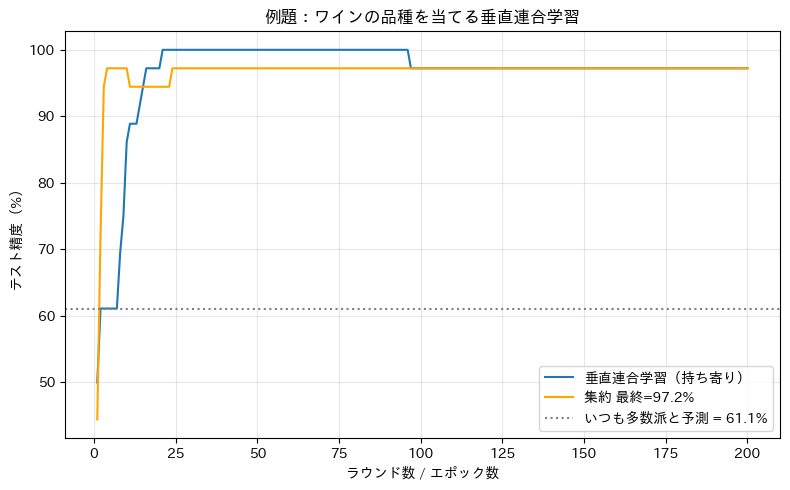

CPU times: user 953 ms, sys: 1.25 ms, total: 954 ms
Wall time: 958 ms


In [14]:
%%time
wine_cent_acc, wine_cent_hist = run_centralized(
    wine_partitions, wine_idx_tr, wine_idx_te, y_wine_tr, y_wine_te)
wine_vfl_acc, wine_vfl_hist, _, _ = run_vertical_fl(
    wine_partitions, wine_idx_tr, wine_idx_te, y_wine_tr, y_wine_te)
wine_naive = max(y_wine.iloc[wine_idx_te].mean(),
                 1 - y_wine.iloc[wine_idx_te].mean()) * 100

print(f"集約            : {wine_cent_acc:.1f}%")
print(f"垂直FL          : {wine_vfl_acc:.1f}%")
print(f"いつも同じ答え（答えとして多い方）にした場合: {wine_naive:.1f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(wine_vfl_hist)+1), wine_vfl_hist, label="垂直連合学習（持ち寄り）")
plt.plot(range(1, len(wine_cent_hist)+1), wine_cent_hist, color="orange",
         label=f"集約 最終={wine_cent_acc:.1f}%")
plt.axhline(wine_naive, color="gray", linestyle=":",
            label=f"いつも同じ答え（答えとして多い方）にした場合 = {wine_naive:.1f}%")
plt.xlabel("ラウンド数 / エポック数"); plt.ylabel("テスト精度（%）")
plt.title("例題：ワインの品種を当てる垂直連合学習")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

データを共有していないのに、垂直連合学習は集約とほぼ同じ精度が出ています。
これが垂直連合学習の完成形です。

次の章では、この流れを **自分の手で** タイタニックのデータに対して組み立てます。
この例題のコードがお手本になるので、迷ったら戻って見比べてください。


## 3. 演習：タイタニックの生存予測（穴埋め）

ここからは、例題（第2章）で見た流れを **自分の手で** 組み立てます。
タイタニック号の乗客データを使い、ある乗客が生き残ったかどうかを予測します。

例題と同じように、特徴を3つのグループに分け、データを見せ合わずに持ち寄って予測します。
迷ったら例題のコードに戻って見比べてください。

### 3-1. データを用意する

In [15]:
# --- Titanic データの取得と前処理 ---
def _bin_age(age_series):
    """年齢を Child / Adult / Elderly の3区分にする"""
    bins = [-np.inf, 10, 40, np.inf]
    labels = ["Child", "Adult", "Elderly"]
    return (pd.cut(age_series, bins=bins, labels=labels, right=True)
            .astype(str).replace("nan", "Unknown"))

def _extract_title(name_series):
    """名前から敬称（Mr, Miss, ...）を取り出す"""
    titles = name_series.str.extract(r" ([A-Za-z]+)\.", expand=False)
    rare = {"Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"}
    titles = titles.replace(list(rare), "Rare")
    titles = titles.replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
    return titles

def _create_features(df):
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    df["Age"] = _bin_age(df["Age"])
    df["Cabin"] = df["Cabin"].str[0].fillna("Unknown")
    df["Title"] = _extract_title(df["Name"])
    df.drop(columns=["PassengerId","Name","Ticket"], inplace=True, errors="ignore")
    df = pd.get_dummies(df, columns=["Sex","Pclass","Embarked","Title","Cabin","Age"])
    return df

def load_titanic():
    URL_TR = "https://raw.githubusercontent.com/agconti/kaggle-titanic/master/data/train.csv"
    URL_TE = "https://raw.githubusercontent.com/agconti/kaggle-titanic/master/data/test.csv"
    DATA_DIR = Path("data_titanic"); os.makedirs(DATA_DIR, exist_ok=True)
    for name, url in [("train.csv", URL_TR), ("test.csv", URL_TE)]:
        fp = DATA_DIR / name
        if not fp.is_file():
            print(f"{name} をダウンロード中...")
            urllib.request.urlretrieve(url, fp)
    train_df = pd.read_csv(DATA_DIR / "train.csv")
    test_df  = pd.read_csv(DATA_DIR / "test.csv")
    # 訓練とテストをまとめて前処理（列をそろえるため）
    combined = pd.concat([train_df.drop("Survived", axis=1), test_df], ignore_index=True)
    y_full = train_df["Survived"]
    processed = _create_features(combined)
    X_full = processed.iloc[:len(train_df)].copy()
    # 正解ラベルのあるデータを、訓練用とテスト用に分ける
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
    return X_train.astype(np.float32), X_test.astype(np.float32), y_train, y_test

X_train, X_test, y_train, y_test = load_titanic()
print(f"訓練データ {len(X_train)}人 / テストデータ {len(X_test)}人")
print(f"全部の特徴の数（前処理後）: {X_train.shape[1]} 個")

train.csv をダウンロード中...
test.csv をダウンロード中...
訓練データ 712人 / テストデータ 179人
全部の特徴の数（前処理後）: 29 個


### 3-2. どんなデータを使うのか見てみよう

In [16]:
# 前処理する前の生のデータを最初の5人だけ表示してみる
raw_df = pd.read_csv("data_titanic/train.csv")
cols_show = ["Survived","Pclass","Name","Sex","Age","SibSp","Parch","Fare","Cabin","Embarked"]
display(raw_df[cols_show].head())

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


各列が表す意味は次のとおりです。

| 列名 | 意味 |
|---|---|
| Survived | 生存(1)か死亡(0)か　← これを予測する |
| Pclass | 客室の等級（1=高級 / 2 / 3） |
| Name | 氏名（敬称 Mr, Miss などを取り出して使う） |
| Sex | 性別 |
| Age | 年齢（子ども / 大人 / 高齢の3区分にする） |
| SibSp | 同乗した兄弟姉妹・配偶者の数 |
| Parch | 同乗した親・子の数 |
| Fare | 運賃 |
| Cabin | 部屋番号（先頭の記号だけ使う） |
| Embarked | 乗船した港 |

※ Sex や Pclass などは、機械学習で扱いやすいように 0/1 の列に変換（ワンホット化）して使います。
下のセルで、実際にどんな値（種類）があるかを確認しましょう。


In [17]:
# どのカテゴリ項目が、どんな値（種類）を持つかを一覧で確認する
# （前処理後の列名から逆算するので、実際に使われる値とぴったり一致します）
jp_name = {"Sex":"性別", "Pclass":"客室の等級", "Embarked":"乗船した港",
           "Title":"敬称", "Cabin":"部屋番号(先頭の記号)", "Age":"年齢区分"}

category_values = {}
for col in X_train.columns:
    if "_" in col:                       # ワンホット化された列（例: Age_Adult）
        prefix = col.split("_")[0]
        value  = col[len(prefix)+1:]
        category_values.setdefault(prefix, []).append(value)

cat_rows = []
for prefix, values in category_values.items():
    cat_rows.append({
        "項目": f"{prefix}（{jp_name.get(prefix, prefix)}）",
        "種類の数": len(values),
        "値の一覧": " / ".join(values),
    })
cat_df = pd.DataFrame(cat_rows)
display(cat_df)

# 数値そのままで使う項目も示す
num_cols = [c for c in X_train.columns if "_" not in c]
print("そのまま数値で使う項目:", ", ".join(num_cols))
print("  （SibSp=同乗の兄弟姉妹・配偶者の数, Parch=同乗の親・子の数, Fare=運賃）")

,項目,種類の数,値の一覧
0,Sex（性別）,2,female / male
1,Pclass（客室の等級）,3,1 / 2 / 3
2,Embarked（乗船した港）,3,C / Q / S
3,Title（敬称）,5,Master / Miss / Mr / Mrs / Rare
4,Cabin（部屋番号(先頭の記号)）,9,A / B / C / D / E / F / G / T / Unknown
5,Age（年齢区分）,4,Adult / Child / Elderly / Unknown


そのまま数値で使う項目: SibSp, Parch, Fare
  （SibSp=同乗の兄弟姉妹・配偶者の数, Parch=同乗の親・子の数, Fare=運賃）


上の表の値（英語）の意味は、次のとおりです。

| 項目 | 英語の値 | 意味 |
|---|---|---|
| Sex（性別） | female / male | 女性 / 男性 |
| Embarked（乗船した港） | C / Q / S | シェルブール港 / クイーンズタウン港 / サウサンプトン港 |
| Title（敬称） | Master / Miss / Mr / Mrs / Rare | 少年 / 未婚女性 / 成人男性 / 既婚女性 / その他まれな敬称 |
| Age（年齢区分） | Child / Adult / Elderly | 子ども（10歳以下） / 大人（11〜40歳） / 高齢（41歳以上） |
| Cabin（部屋番号の先頭） | A〜T / Unknown | 客室の甲板を表す記号 / 不明 |
| Pclass（客室の等級） | 1 / 2 / 3 | 1等 / 2等 / 3等 |


### 3-3. 特徴を3つのグループに分ける（垂直分割）

例題ではデータが最初から分かれていましたが、ここでは1つのデータを3つのグループに分けます。

In [18]:
def split_features_vertically(df, num_clients):
    """特徴量（列）を num_clients グループに縦に分割する"""
    col_groups = np.array_split(df.columns, num_clients)
    return [df[list(cols)].copy() for cols in col_groups]

# 実際に3人で分けてみる
parts = split_features_vertically(X_train, NUM_CLIENTS)

# 誰がどの特徴を持っているかを表にする
summary = pd.DataFrame([
    {"参加者": f"参加者{i+1}",
     "持っている特徴の数": p.shape[1],
     "特徴の例": ", ".join(list(p.columns)[:3]) + " ..."}
    for i, p in enumerate(parts)])
display(summary)

# 列名（英語）→ 日本語の意味の対応
col_jp = {
    "SibSp": "兄弟姉妹・配偶者の数", "Parch": "親・子の数", "Fare": "運賃",
    "Sex_female": "性別=女性", "Sex_male": "性別=男性",
    "Pclass_1": "客室1等", "Pclass_2": "客室2等", "Pclass_3": "客室3等",
    "Embarked_C": "乗船港=シェルブール", "Embarked_Q": "乗船港=クイーンズタウン",
    "Embarked_S": "乗船港=サウサンプトン",
    "Title_Master": "敬称=少年", "Title_Miss": "敬称=未婚女性", "Title_Mr": "敬称=成人男性",
    "Title_Mrs": "敬称=既婚女性", "Title_Rare": "敬称=その他",
    "Cabin_A": "部屋=A甲板", "Cabin_B": "部屋=B甲板", "Cabin_C": "部屋=C甲板",
    "Cabin_D": "部屋=D甲板", "Cabin_E": "部屋=E甲板", "Cabin_F": "部屋=F甲板",
    "Cabin_G": "部屋=G甲板", "Cabin_T": "部屋=T甲板", "Cabin_Unknown": "部屋=不明",
    "Age_Adult": "年齢=大人", "Age_Child": "年齢=子ども",
    "Age_Elderly": "年齢=高齢", "Age_Unknown": "年齢=不明",
}

print("\n--- それぞれが持つ特徴の中身（全部）---")
for i, p in enumerate(parts):
    print(f"\n参加者{i+1}:")
    for c in p.columns:
        print(f"    {c}（{col_jp.get(c, c)}）")

,参加者,持っている特徴の数,特徴の例
0,参加者1,10,"SibSp, Parch, Fare ..."
1,参加者2,10,"Embarked_S, Title_Master, Title_Miss ..."
2,参加者3,9,"Cabin_E, Cabin_F, Cabin_G ..."



--- それぞれが持つ特徴の中身（全部）---

参加者1:
    SibSp（兄弟姉妹・配偶者の数）
    Parch（親・子の数）
    Fare（運賃）
    Sex_female（性別=女性）
    Sex_male（性別=男性）
    Pclass_1（客室1等）
    Pclass_2（客室2等）
    Pclass_3（客室3等）
    Embarked_C（乗船港=シェルブール）
    Embarked_Q（乗船港=クイーンズタウン）

参加者2:
    Embarked_S（乗船港=サウサンプトン）
    Title_Master（敬称=少年）
    Title_Miss（敬称=未婚女性）
    Title_Mr（敬称=成人男性）
    Title_Mrs（敬称=既婚女性）
    Title_Rare（敬称=その他）
    Cabin_A（部屋=A甲板）
    Cabin_B（部屋=B甲板）
    Cabin_C（部屋=C甲板）
    Cabin_D（部屋=D甲板）

参加者3:
    Cabin_E（部屋=E甲板）
    Cabin_F（部屋=F甲板）
    Cabin_G（部屋=G甲板）
    Cabin_T（部屋=T甲板）
    Cabin_Unknown（部屋=不明）
    Age_Adult（年齢=大人）
    Age_Child（年齢=子ども）
    Age_Elderly（年齢=高齢）
    Age_Unknown（年齢=不明）


In [19]:
# 例題の関数（run_vertical_fl / run_centralized）に合わせて、データを整える
# 1つのデータを3グループに分け、訓練用とテスト用は番号（インデックス）で指定する
X_full_tt = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full_tt = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

titanic_partitions = split_features_vertically(X_full_tt, NUM_CLIENTS)

tt_idx_tr = np.arange(len(X_train))
tt_idx_te = np.arange(len(X_train), len(X_full_tt))
y_tt_t = torch.tensor(y_full_tt.values, dtype=torch.float32).unsqueeze(1)
y_tt_tr, y_tt_te = y_tt_t[tt_idx_tr], y_tt_t[tt_idx_te]
print("データ準備 完了")

データ準備 完了


### 3-4. 垂直連合学習を自分で書く（穴埋め）

いよいよ本番です。**データは渡さず**、次の3ステップを繰り返します。

1. **ステップ①**：各参加者が自分のデータから中間の特徴を計算し、サーバーへ送る
2. **ステップ②**：サーバーが3人分の中間の特徴を結合して学習し、予測の誤差を計算する
3. **ステップ③**：サーバーが、中間の特徴をどう直せばよいか（勾配）を各参加者に返し、各参加者が自分のモデルを更新する

この往復を繰り返すだけで、生データを一度も共有せずに学習が進みます。

> **統合のときのキーについて**
> サーバーが3人分の中間の特徴を結合するとき、何行目が誰のデータかが3者で揃っていることが前提です。
> つまり、各参加者のデータの **並び順（同じ人が同じ行にいること）** が統合のキーになります。
>
> 今回のチュートリアルでは、もともと1つのデータを列で分けているので並び順は自動的に揃っています。
> ですが現実の垂直連合学習では、各組織がバラバラの順序でデータを持っているのが普通です。
> その場合は、まず **顧客IDやマイナンバーのような共通の番号** を使ってどの行が同じ人かを対応づけ、
> 共通して存在する人だけを同じ順序に並べてから学習します。今回は、その対応づけが済んだ後の状態を扱っています。


例題の `run_vertical_fl` を思い出して、3つのステップ（穴埋め①②③）を完成させてください。

In [21]:
def run_vertical_fl(partitions, idx_tr, idx_te, ytr, yte,
                    rounds=200, client_lr=0.5, server_lr=0.01, seed=0):
    torch.manual_seed(seed)

    # 各参加者：自分のデータを標準化して持つ（訓練用の値で基準を作り、両方に適用）
    client_data_tr, client_data_te = [], []
    for p in partitions:
        arr = p.values
        scaler = StandardScaler().fit(arr[idx_tr])
        client_data_tr.append(torch.tensor(scaler.transform(arr[idx_tr]), dtype=torch.float32))
        client_data_te.append(torch.tensor(scaler.transform(arr[idx_te]), dtype=torch.float32))

    client_models = [ClientModel(d.shape[1]) for d in client_data_tr]
    client_opts   = [torch.optim.SGD(m.parameters(), lr=client_lr) for m in client_models]
    server_model  = ServerModel(EMB_DIM * len(partitions))
    server_opt    = torch.optim.Adam(server_model.parameters(), lr=server_lr)
    criterion     = nn.BCELoss()

    history = []
    for r in range(rounds):
        # === ステップ① 各参加者が中間の特徴を計算してサーバーへ送る ===
        # 【穴埋め①】各参加者モデル m に自分のデータ d を入れて、中間の特徴のリストを作る
        embeddings = [m(d) for m, d in zip(client_models, client_data_tr)]
        emb_cat = torch.cat([e.detach() for e in embeddings], dim=1).requires_grad_()

        # === ステップ② サーバーが中間の特徴を結合して学習する ===
        # 【穴埋め②】サーバーモデルに emb_cat を入れて予測 output を出し、正解 ytr との誤差 loss を計算する
        output = server_model(emb_cat)
        loss = criterion(output, ytr)
        server_opt.zero_grad(); loss.backward(); server_opt.step()

        # === ステップ③ 中間の特徴に対する勾配を各参加者に返し、各自が学習する ===
        grads = emb_cat.grad.split([EMB_DIM] * len(partitions), dim=1)
        # 【穴埋め③】各参加者で、勾配の初期化 -> 自分の中間の特徴に勾配gを逆伝播 -> パラメータ更新 を行う
        for m, o, e, g in zip(client_models, client_opts, embeddings, grads):
            o.zero_grad(); e.backward(g); o.step()

        with torch.no_grad():
            emb_te = torch.cat([m(d) for m, d in zip(client_models, client_data_te)], dim=1)
            acc = ((server_model(emb_te) > 0.5).float() == yte).float().mean().item() * 100
        history.append(acc)

    return history[-1], history, server_model, client_models

#### ✅ 答え合わせ（穴埋めのチェック）

小さく試運転して、3つのステップが正しく書けているか確認します。
正しく書けていれば、短い学習でも精度がベースライン（いつも同じ答え（答えとして多い方）にした場合）を十分に上回ります。

In [22]:
# 短い学習（20ラウンド）で試運転して確認する
_check_acc, _, _, _ = run_vertical_fl(
    titanic_partitions, tt_idx_tr, tt_idx_te, y_tt_tr, y_tt_te, rounds=20)
_baseline = max(y_full_tt.iloc[tt_idx_te].mean(),
                1 - y_full_tt.iloc[tt_idx_te].mean()) * 100
_threshold = _baseline + 10

print(f"試運転の精度: {_check_acc:.1f}%（合格ライン: {_threshold:.1f}% 以上）")
if _check_acc >= _threshold:
    print("✅ OK：3つのステップが正しく書けています。次に進みましょう。")
else:
    print("❌ もう一度確認しましょう。例題の run_vertical_fl と見比べてください。")
    print("   ・① 各参加者が中間の特徴を計算できていますか？")
    print("   ・② サーバーが予測と誤差(loss)を計算できていますか？")
    print("   ・③ 勾配を各参加者に返して、各自が学習できていますか？")

試運転の精度: 79.9%（合格ライン: 71.5% 以上）
✅ OK：3つのステップが正しく書けています。次に進みましょう。


### 3-5. 集約と垂直連合学習を比べる

集約            : 78.8%
垂直FL          : 80.4%
いつも多数派の死亡と予測: 61.5%


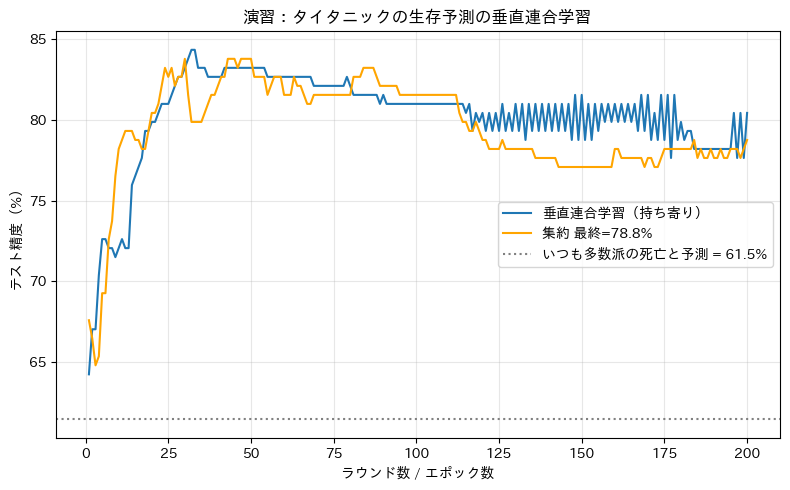

CPU times: user 1.01 s, sys: 7.3 ms, total: 1.01 s
Wall time: 1.02 s


In [23]:
%%time
tt_cent_acc, tt_cent_hist = run_centralized(
    titanic_partitions, tt_idx_tr, tt_idx_te, y_tt_tr, y_tt_te)
tt_vfl_acc, tt_vfl_hist, tt_server, tt_clients = run_vertical_fl(
    titanic_partitions, tt_idx_tr, tt_idx_te, y_tt_tr, y_tt_te)
tt_naive = max(y_full_tt.iloc[tt_idx_te].mean(),
               1 - y_full_tt.iloc[tt_idx_te].mean()) * 100

print(f"集約            : {tt_cent_acc:.1f}%")
print(f"垂直FL          : {tt_vfl_acc:.1f}%")
print(f"いつも同じ答え（答えとして多い方）にした場合: {tt_naive:.1f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(tt_vfl_hist)+1), tt_vfl_hist, label="垂直連合学習（持ち寄り）")
plt.plot(range(1, len(tt_cent_hist)+1), tt_cent_hist, color="orange",
         label=f"集約 最終={tt_cent_acc:.1f}%")
plt.axhline(tt_naive, color="gray", linestyle=":",
             label=f"いつも同じ答え（答えとして多い方）にした場合 = {tt_naive:.1f}%")
plt.xlabel("ラウンド数 / エポック数"); plt.ylabel("テスト精度（%）")
plt.title("演習：タイタニックの生存予測の垂直連合学習")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

データを一度も共有していないのに、垂直連合学習は集約とほぼ同じ精度が出ています。

（タイタニックは情報量が限られるため、集約も垂直FLもどちらも80%前後が実力の上限です。）

### 3-6. 自由実習：条件を変えて試してみよう

下の数字を書き換えて、精度がどう変わるか観察してみましょう。

- `rounds`：学習の往復回数（上限 300）
- `server_lr`：サーバーの学習スピード（0.001〜0.05 くらい）
- `client_lr`：参加者の学習スピード（0.1〜1.0 くらい）

あなたの設定での精度: 80.4%


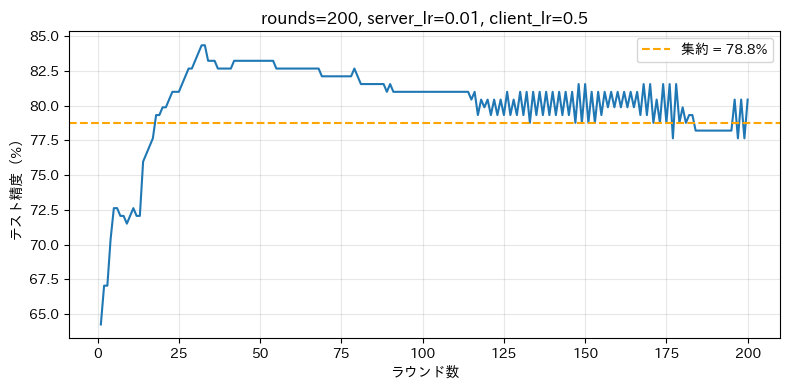

CPU times: user 759 ms, sys: 1.06 ms, total: 760 ms
Wall time: 781 ms


In [24]:
%%time
my_rounds    = 200
my_server_lr = 0.01
my_client_lr = 0.5
my_rounds = min(my_rounds, 300)   # 上限の歯止め

acc, hist, _, _ = run_vertical_fl(
    titanic_partitions, tt_idx_tr, tt_idx_te, y_tt_tr, y_tt_te,
    rounds=my_rounds, server_lr=my_server_lr, client_lr=my_client_lr)
print(f"あなたの設定での精度: {acc:.1f}%")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(hist)+1), hist)
plt.axhline(tt_cent_acc, color="orange", linestyle="--", label=f"集約 = {tt_cent_acc:.1f}%")
plt.xlabel("ラウンド数"); plt.ylabel("テスト精度（%）")
plt.title(f"rounds={my_rounds}, server_lr={my_server_lr}, client_lr={my_client_lr}")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. 発展課題：電話会社の解約予測（穴埋め・難しめ）

ここからは、本編より少し難しい発展課題です。
別のデータセットで、垂直連合学習をより広い範囲まで自分で組み立てます。
例題（第2章）の `run_vertical_fl` をよく見ながら、空欄を埋めてください。

**お題：電話会社の顧客データで解約を予測する（Telco Customer Churn）**

電話会社の顧客データを使い、ある顧客が解約するかどうかを予測します。
このデータには、顧客の属性・契約しているサービス・契約期間や料金といった、
さまざまな種類の情報が含まれています。

今回はこれらの情報を **3つのグループ** に分け、本編と同じ垂直連合学習の手順で、
それぞれのグループを持ち寄って解約予測ができるか試します。

- グループ1：顧客の属性（性別・高齢者かどうか・家族構成 など）
- グループ2：契約しているサービス（電話・ネット・各種オプション など）
- グループ3：契約期間と料金（契約期間・支払い方法・月額料金 など）

### 4-1. データの準備（穴埋め①〜②）

このデータはインターネット上の公開データを使います（認証は不要です）。
まず、どんなデータなのかを確認しましょう。

In [25]:
import urllib.request, io

# 公開データを読み込む
telco_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
_req = urllib.request.Request(telco_url, headers={"User-Agent": "Mozilla/5.0"})
telco = pd.read_csv(io.BytesIO(urllib.request.urlopen(_req).read()))

# 前処理：使わないID列を消す／料金を数値に直す／予測対象を 0,1 にする
telco = telco.drop(columns=["customerID"])
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce").fillna(0)
y_telco = (telco["Churn"] == "Yes").astype(int)   # 解約=1, 継続=0
telco = telco.drop(columns=["Churn"])

print(f"顧客の数: {len(telco)}人 / 情報の種類: {telco.shape[1]}個")
print(f"継続（No）: {(y_telco==0).sum()}人 / 解約（Yes）: {(y_telco==1).sum()}人")
display(telco.head(3))

顧客の数: 7043人 / 情報の種類: 19個
継続（No）: 5174人 / 解約（Yes）: 1869人


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15


列名（英語）の意味は、次のとおりです。

| 列名 | 意味 |
|---|---|
| gender | 性別（Female=女性 / Male=男性） |
| SeniorCitizen | 高齢者かどうか（1=高齢者 / 0=そうでない） |
| Partner | 配偶者・パートナーがいるか（Yes / No） |
| Dependents | 扶養家族がいるか（Yes / No） |
| tenure | 契約してからの月数 |
| PhoneService | 電話サービスの契約（Yes / No） |
| MultipleLines | 複数回線の契約（Yes / No / No phone service=電話契約なし） |
| InternetService | ネット回線の種類（DSL / Fiber optic=光回線 / No=契約なし） |
| OnlineSecurity | セキュリティオプション（Yes / No / No internet service=ネット契約なし） |
| OnlineBackup | バックアップオプション（Yes / No / ネット契約なし） |
| DeviceProtection | 端末保証オプション（Yes / No / ネット契約なし） |
| TechSupport | 技術サポート（Yes / No / ネット契約なし） |
| StreamingTV | TV配信サービス（Yes / No / ネット契約なし） |
| StreamingMovies | 映画配信サービス（Yes / No / ネット契約なし） |
| Contract | 契約期間（Month-to-month=月単位 / One year=1年 / Two year=2年） |
| PaperlessBilling | ペーパーレス請求（Yes / No） |
| PaymentMethod | 支払い方法（電子小切手 / 郵送小切手 / 銀行振込 / クレジットカード） |
| MonthlyCharges | 月額料金 |
| TotalCharges | これまでの合計支払額 |

予測対象は **Churn**（解約したか：Yes=解約 / No=継続）です。

### どのグループがどの情報を持つか（分割の指定）

3つのグループに含める情報は、次のように **最初から決まっています**。

| グループ | 含まれる情報 | 列名 |
|---|---|---|
| グループ1（顧客の属性） | 顧客の属性 | gender, SeniorCitizen, Partner, Dependents |
| グループ2（契約サービス） | 契約しているサービス | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| グループ3（契約と料金） | 契約期間と料金 | tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges |

この指定に従って、次のセルの空欄を埋めてください。

In [26]:
# 【穴埋め①】上の表の指定どおり、3つのグループが持つ列のリストを作る
dept_customer = ["gender", "SeniorCitizen", "Partner", "Dependents"]
dept_service  = ["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
                 "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
                 "StreamingMovies"]
dept_contract = ["tenure", "Contract", "PaperlessBilling", "PaymentMethod",
                 "MonthlyCharges", "TotalCharges"]

dept_cols = [dept_customer, dept_service, dept_contract]
dept_names = ["グループ1（顧客の属性）", "グループ2（契約サービス）", "グループ3（契約と料金）"]

# 【穴埋め②】各グループの列を、機械学習で使える数値の表に変換する（ワンホット化）
#   ヒント：pd.get_dummies(...) を使い、最後に .astype(np.float32) で数値の型をそろえる
def make_partition(cols):
    return pd.get_dummies(telco[cols]).astype(np.float32)

telco_partitions = [make_partition(cols) for cols in dept_cols]

# 各グループが何個の特徴を持つか確認
size_df = pd.DataFrame([
    {"グループ": name, "元の列数": len(cols), "変換後の特徴数": p.shape[1]}
    for name, cols, p in zip(dept_names, dept_cols, telco_partitions)])
display(size_df)

# ✅ 答え合わせ（穴埋め①②のチェック）
_ok = True
if sorted(dept_customer + dept_service + dept_contract) != sorted(telco.columns):
    print("❌ 穴埋め①：3グループの列を合わせると、全部の列がちょうど1回ずつ現れるはずです。指定を見直しましょう。")
    _ok = False
if not all(str(p.values.dtype) == "float32" for p in telco_partitions):
    print("❌ 穴埋め②：pd.get_dummies(...) のあと .astype(np.float32) になっているか確認しましょう。")
    _ok = False
if _ok:
    print("✅ OK：3つのグループに、過不足なく列を振り分けられています。")

,グループ,元の列数,変換後の特徴数
0,グループ1（顧客の属性）,4,7
1,グループ2（契約サービス）,9,26
2,グループ3（契約と料金）,6,12


✅ OK：3つのグループに、過不足なく列を振り分けられています。


In [27]:
# 訓練用とテスト用に分ける（どの顧客を訓練/テストにするかを番号で決める）
telco_idx_tr, telco_idx_te = train_test_split(
    np.arange(len(telco)), test_size=0.2, random_state=42, stratify=y_telco)
y_telco_t = torch.tensor(y_telco.values, dtype=torch.float32).unsqueeze(1)
y_telco_tr, y_telco_te = y_telco_t[telco_idx_tr], y_telco_t[telco_idx_te]
print("データ準備 完了")

データ準備 完了


### 4-2. 垂直連合学習を自分で書く（穴埋め③〜⑩・難しめ）

ここが発展課題の本番です。例題の `run_vertical_fl` を見ながら、関数の中身を広い範囲まで自分で書いてください。
各空欄には、何をするかのコメントが付いています。骨組み（for ループや return）は残してあります。

In [28]:
def run_vertical_fl_advanced(partitions, idx_tr, idx_te, ytr, yte,
                             rounds=200, client_lr=0.5, server_lr=0.01, seed=0):
    torch.manual_seed(seed)

    # 各グループ：自分のデータを標準化して持つ（訓練用の値で基準を作り、訓練用とテスト用の両方に適用）
    client_data_tr, client_data_te = [], []
    for p in partitions:
        arr = p.values
        # 【穴埋め③】訓練用データ arr[idx_tr] を使って標準化の基準（scaler）を作る
        scaler = StandardScaler().fit(arr[idx_tr])
        # 【穴埋め④】その基準で訓練用・テスト用を変換し、torch.float32 のテンソルにして各リストに追加する
        client_data_tr.append(torch.tensor(scaler.transform(arr[idx_tr]), dtype=torch.float32))
        client_data_te.append(torch.tensor(scaler.transform(arr[idx_te]), dtype=torch.float32))

    # 【穴埋め⑤】各グループのモデル（ClientModel）を、特徴数 d.shape[1] で作りリストにする
    client_models = [ClientModel(d.shape[1]) for d in client_data_tr]
    # 【穴埋め⑥】各グループのオプティマイザ（SGD・学習率 client_lr）を作りリストにする
    client_opts   = [torch.optim.SGD(m.parameters(), lr=client_lr) for m in client_models]
    # 【穴埋め⑦】サーバーモデル（ServerModel）を、入力サイズ EMB_DIM×グループ数 で作る
    server_model  = ServerModel(EMB_DIM * len(partitions))
    server_opt    = torch.optim.Adam(server_model.parameters(), lr=server_lr)
    criterion     = nn.BCELoss()

    history = []
    for r in range(rounds):
        # === ステップ① 各グループが中間の特徴を計算してサーバーへ送る ===
        # 【穴埋め⑧】各グループモデル m に自分のデータ d を入れて、中間の特徴のリストを作る
        embeddings = [m(d) for m, d in zip(client_models, client_data_tr)]
        emb_cat = torch.cat([e.detach() for e in embeddings], dim=1).requires_grad_()

        # === ステップ② サーバーが中間の特徴を結合して学習する ===
        # 【穴埋め⑨】サーバーモデルに emb_cat を入れて予測 output を出し、正解 ytr との誤差 loss を計算する
        output = server_model(emb_cat)
        loss = criterion(output, ytr)
        server_opt.zero_grad(); loss.backward(); server_opt.step()

        # === ステップ③ 中間の特徴に対する勾配を各グループに返し、各自が学習する ===
        grads = emb_cat.grad.split([EMB_DIM] * len(partitions), dim=1)
        # 【穴埋め⑩】各グループで、勾配の初期化 -> 自分の中間の特徴に勾配gを逆伝播 -> パラメータ更新 を行う
        for m, o, e, g in zip(client_models, client_opts, embeddings, grads):
            o.zero_grad(); e.backward(g); o.step()

        with torch.no_grad():
            emb_te = torch.cat([m(d) for m, d in zip(client_models, client_data_te)], dim=1)
            acc = ((server_model(emb_te) > 0.5).float() == yte).float().mean().item() * 100
        history.append(acc)

    return history[-1], history

#### ✅ 答え合わせ（穴埋め③〜⑩のチェック）

小さく試運転して、正しく書けているか確認します。

In [29]:
# 短い学習（20ラウンド）で試運転して確認する
_check_acc, _ = run_vertical_fl_advanced(
    telco_partitions, telco_idx_tr, telco_idx_te, y_telco_tr, y_telco_te, rounds=20)
_baseline = max(y_telco.iloc[telco_idx_te].mean(),
                1 - y_telco.iloc[telco_idx_te].mean()) * 100
_threshold = _baseline + 3

print(f"試運転の精度: {_check_acc:.1f}%（合格ライン: {_threshold:.1f}% 以上）")
if _check_acc >= _threshold:
    print("✅ OK：正しく書けています。次に進みましょう。")
else:
    print("❌ もう一度確認しましょう。例題の run_vertical_fl と1行ずつ見比べてください。")
    print("   ・標準化（scaler）やモデル・オプティマイザの用意はできていますか？")
    print("   ・① 中間の特徴の計算 / ② 予測と誤差 / ③ 勾配を返して各自が学習、はできていますか？")

試運転の精度: 77.8%（合格ライン: 76.5% 以上）
✅ OK：正しく書けています。次に進みましょう。


### 4-3. 集約と垂直連合学習を比べる

集約            : 77.2%
垂直FL          : 79.1%
いつも多数派の継続と予測: 73.5%


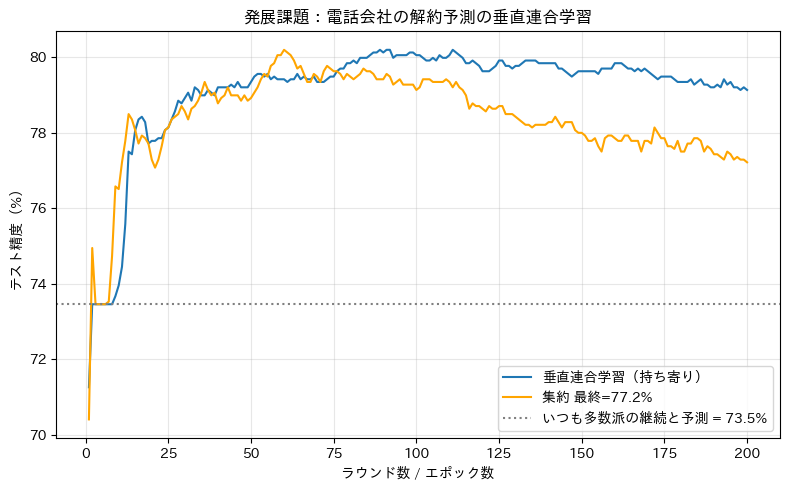

CPU times: user 2.9 s, sys: 5.66 ms, total: 2.9 s
Wall time: 4.97 s


In [30]:
%%time
# 比較用：集約（全グループのデータを1か所に集めて学習）は例題の run_centralized をそのまま使える
telco_cent_acc, telco_cent_hist = run_centralized(
    telco_partitions, telco_idx_tr, telco_idx_te, y_telco_tr, y_telco_te)
telco_vfl_acc, telco_vfl_hist = run_vertical_fl_advanced(
    telco_partitions, telco_idx_tr, telco_idx_te, y_telco_tr, y_telco_te)
telco_naive = max(y_telco.iloc[telco_idx_te].mean(),
                  1 - y_telco.iloc[telco_idx_te].mean()) * 100

print(f"集約            : {telco_cent_acc:.1f}%")
print(f"垂直FL          : {telco_vfl_acc:.1f}%")
print(f"いつも同じ答え（答えとして多い方）にした場合: {telco_naive:.1f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(telco_vfl_hist)+1), telco_vfl_hist, label="垂直連合学習（持ち寄り）")
plt.plot(range(1, len(telco_cent_hist)+1), telco_cent_hist, color="orange",
         label=f"集約 最終={telco_cent_acc:.1f}%")
plt.axhline(telco_naive, color="gray", linestyle=":",
            label=f"いつも同じ答え（答えとして多い方）にした場合 = {telco_naive:.1f}%")
plt.xlabel("ラウンド数 / エポック数"); plt.ylabel("テスト精度（%）")
plt.title("発展課題：電話会社の解約予測の垂直連合学習")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

別のデータでも、同じ仕組みで集約に近い精度が出せました。

垂直連合学習は、タイタニックのような一般的なデータでも、電話会社の顧客データのようなビジネスデータでも、
**生データを共有せずに、別々のグループに分かれた情報を持ち寄って学習できる**ことが確認できました。

## 5. 考察課題

ここまでの実習をふりかえって、次の問いを考えてみましょう。
（正解が1つに決まる問題ではありません。自分の言葉で説明してみてください。）

**問1.** 集約（全部のデータを1か所に集めて学習）と垂直連合学習で、精度にほとんど差が出ませんでした。
データを共有していない垂直連合学習でも、集約に近い精度が出せたのはなぜでしょうか。自分の言葉で説明してみましょう。

**問2.** 演習（3-6）の自由実習で、ラウンド数や学習スピード（server_lr・client_lr）を変えたとき、精度はどう変化しましたか。
うまくいった設定とうまくいかなかった設定を挙げ、その理由を考えてみましょう。

**問3.** 演習（タイタニック）と発展課題（電話会社）で、垂直連合学習の精度と、いつも同じ答え（答えとして多い方）にした場合の精度の差を比べてみましょう。
どちらのほうが垂直連合学習の効果が大きかったでしょうか。そのデータの性質（予測のしやすさなど）から理由を考えてみましょう。

**問4.** 垂直連合学習が役に立ちそうな身近な例を、このチュートリアル以外で1つ考えてみましょう。
複数の組織が同じ人について違う情報を持っている状況です。
どんな組織が何のデータを持ち寄り、何を予測すると便利か、説明してみましょう。

---

### 解答例・着眼点（模範解答版）

**問1の着眼点.**
各参加者は生データではなく中間の特徴を送っており、この中間の特徴には予測に必要な情報がうまく圧縮されている。
サーバーはそれを結合して学習し、勾配を返すことで各参加者のモデルも一緒に育っていく。
結果として、データを1か所に集めて学習した場合（集約）と同じような情報がモデル全体に行きわたるため、精度が近くなる。

**問2の着眼点.**
ラウンド数を増やすと精度は安定する方向だが、ある程度で頭打ちになり、増やしすぎても大きくは変わらない。
学習スピードを大きくしすぎると学習が不安定になり、小さすぎると学習がなかなか進まない。
適度な学習スピードで十分な回数くり返すとよい、という観察が得られていれば十分。

**問3の着眼点.**
電話会社のほうが、いつも同じ答え（答えとして多い方）にした場合の精度（約73%）が高く、垂直FL（約79%）との差は小さめ。
タイタニックは同じ答えにした場合（約62%）に対し垂直FL（約78%）で差が大きい。
これは、電話会社のデータはもともと答えとして多い方（継続）に偏っていて当てやすく、
タイタニックは生死が半々に近く、特徴をうまく使わないと当てられないため、と説明できる。
答えの偏り（多い方の割合）に着目できていればよい。

**問4の着眼点.**
正解は一つではない。複数組織が同じ人の違う情報を持つ例であればよい。
例：病院（検査結果）と薬局（薬の購入履歴）が、同じ患者の健康リスクを予測する。
例：銀行（口座の動き）とECサイト（購買履歴）が、同じ利用者の与信（お金を貸せるか）を判断する。
例：学校（成績）と図書館（貸出履歴）が、同じ生徒の学習傾向を分析する。
データを1か所に集めずに予測したい理由（プライバシーや組織の壁）にも触れられていれば、なお良い。


## 6. まとめと、連合学習研究の広がり

今日学んだこと：
- **垂直連合学習**は、同じ対象について違う特徴を別々の組織が持つときの方法
- データそのものは渡さず、**中間の特徴と勾配**だけをやり取りする
- それでも、全部を集めて学習した場合（集約）に**近い精度**が出せる

連合学習はここからさらに広がります——通信を暗号化してより安全にする、
一度学習した内容を忘れさせる **機械学習アンラーニング**、
カメラやロボットなど現実世界の機器どうしで協調する研究などです。

お疲れさまでした！
